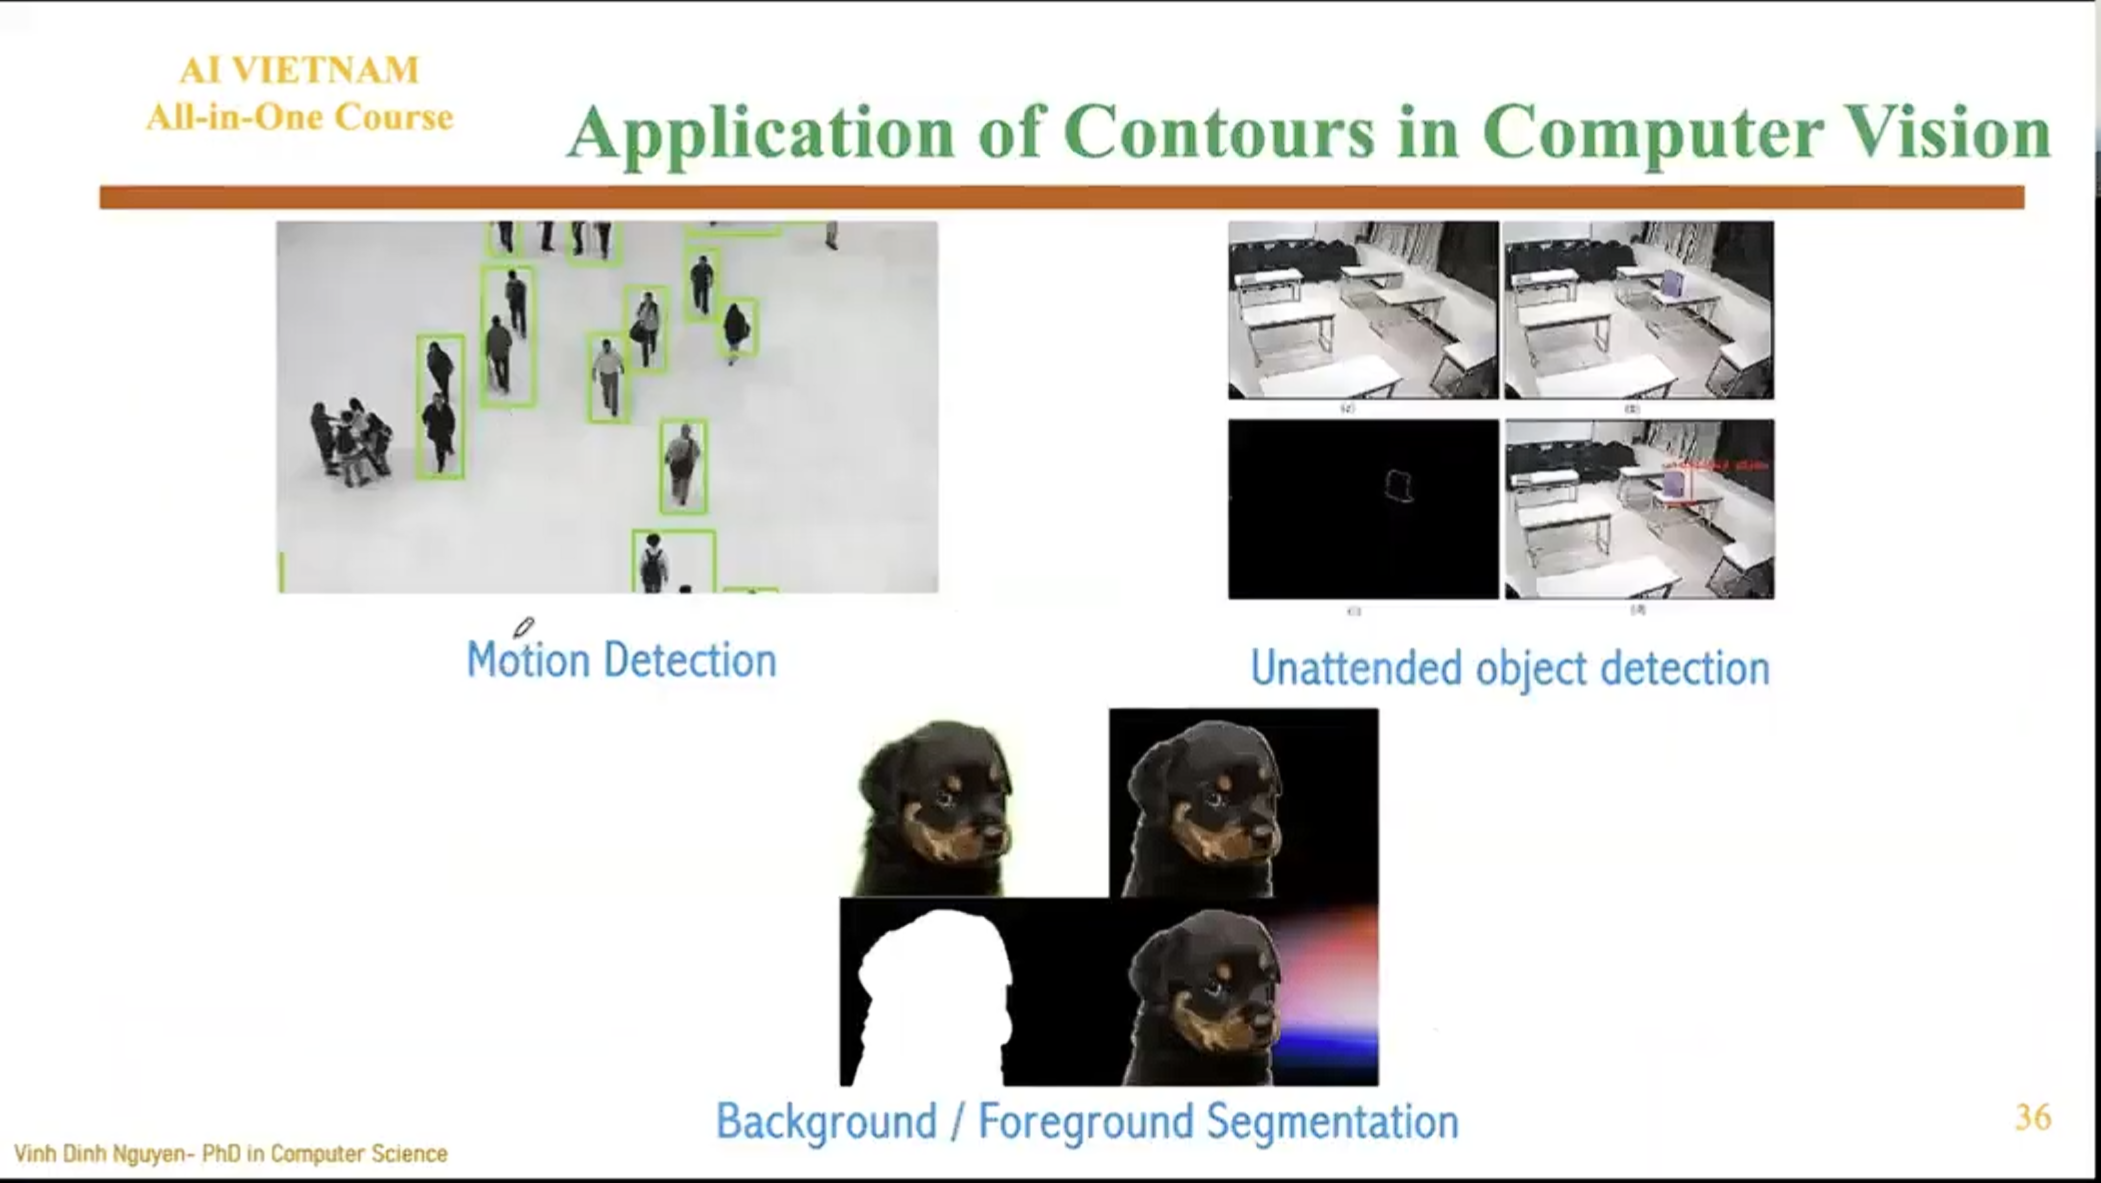

Ý nghĩa chính cốt lõi của Contour Detection là tìm và kết nối các điểm liên tục dọc theo ranh giới của một đối tượng để tạo thành một đường khép kín hoàn chỉnh (thường áp dụng trên ảnh nhị phân đã qua Canny hoặc Thresholding).

**1. Phân tích và nhận dạng hình dáng (Shape Analysis)**

- Edge Detection (như Canny) chỉ trả về một đống pixel màu trắng lộn xộn. Nó không biết các pixel đó thuộc về cái gì.
- Contour Detection gom nhóm các pixel đó lại thành một mảng (array) dữ liệu đại diện cho một ranh giới khép kín. Nhờ đó, máy tính có thể "hiểu" và phân loại được: đường viền này là hình vuông, hình tròn, hình ngôi sao hay một hình dạng tự do nào đó.

**2. Tính toán các đặc trưng hình học (Feature Extraction)**

Đây là giá trị lớn nhất của Contour. Khi bạn đã "gói" được vật thể bằng một đường viền khép kín, bạn có thể dễ dàng dùng các hàm toán học để tính ra:
- Diện tích (Area): Kích thước bề mặt của vật thể.

- Chu vi (Perimeter): Độ dài đường viền bao quanh.

- Trọng tâm (Centroid/Center of Mass): Tọa độ điểm chính giữa của vật thể (rất hữu ích để robot gắp thả đồ vật).

- Khung bao chuẩn (Bounding Box / Minimum Enclosing Circle): Vẽ một hình chữ nhật hoặc hình tròn gọn gàng nhất bọc lấy vật thể để khoanh vùng (giống như các ô vuông bạn hay thấy khi camera nhận diện khuôn mặt).

**3. Đếm và tách đối tượng (Object Counting & Segmentation)**

- Vì mỗi Contour đại diện cho một đối tượng độc lập, bạn có thể dùng nó để đếm số lượng vật thể trong ảnh (ví dụ: đếm xem có bao nhiêu tế bào trong mẫu hiển vi, có bao nhiêu đồng xu trên bàn). Ngoài ra, bạn có thể dùng đường viền này như một "cái kéo" để cắt (crop) riêng đối tượng đó ra khỏi nền tảng (background) phức tạp.

**Sự khác biệt cốt lõi: Edge Detection vs Contour Detection**

- Nếu bạn chụp ảnh một chiếc lá, Canny (Edge) sẽ tìm ra viền ngoài của chiếc lá cộng thêm tất cả các đường gân lá chi chít bên trong (vì cứ có chênh lệch sáng tối là Canny bắt).

- Contour sẽ đi dọc theo mép ngoài cùng, nối liền mép đó lại để tạo thành một đường bao duy nhất đại diện cho "chiếc lá", bỏ qua các gân lá rườm rà bên trong.

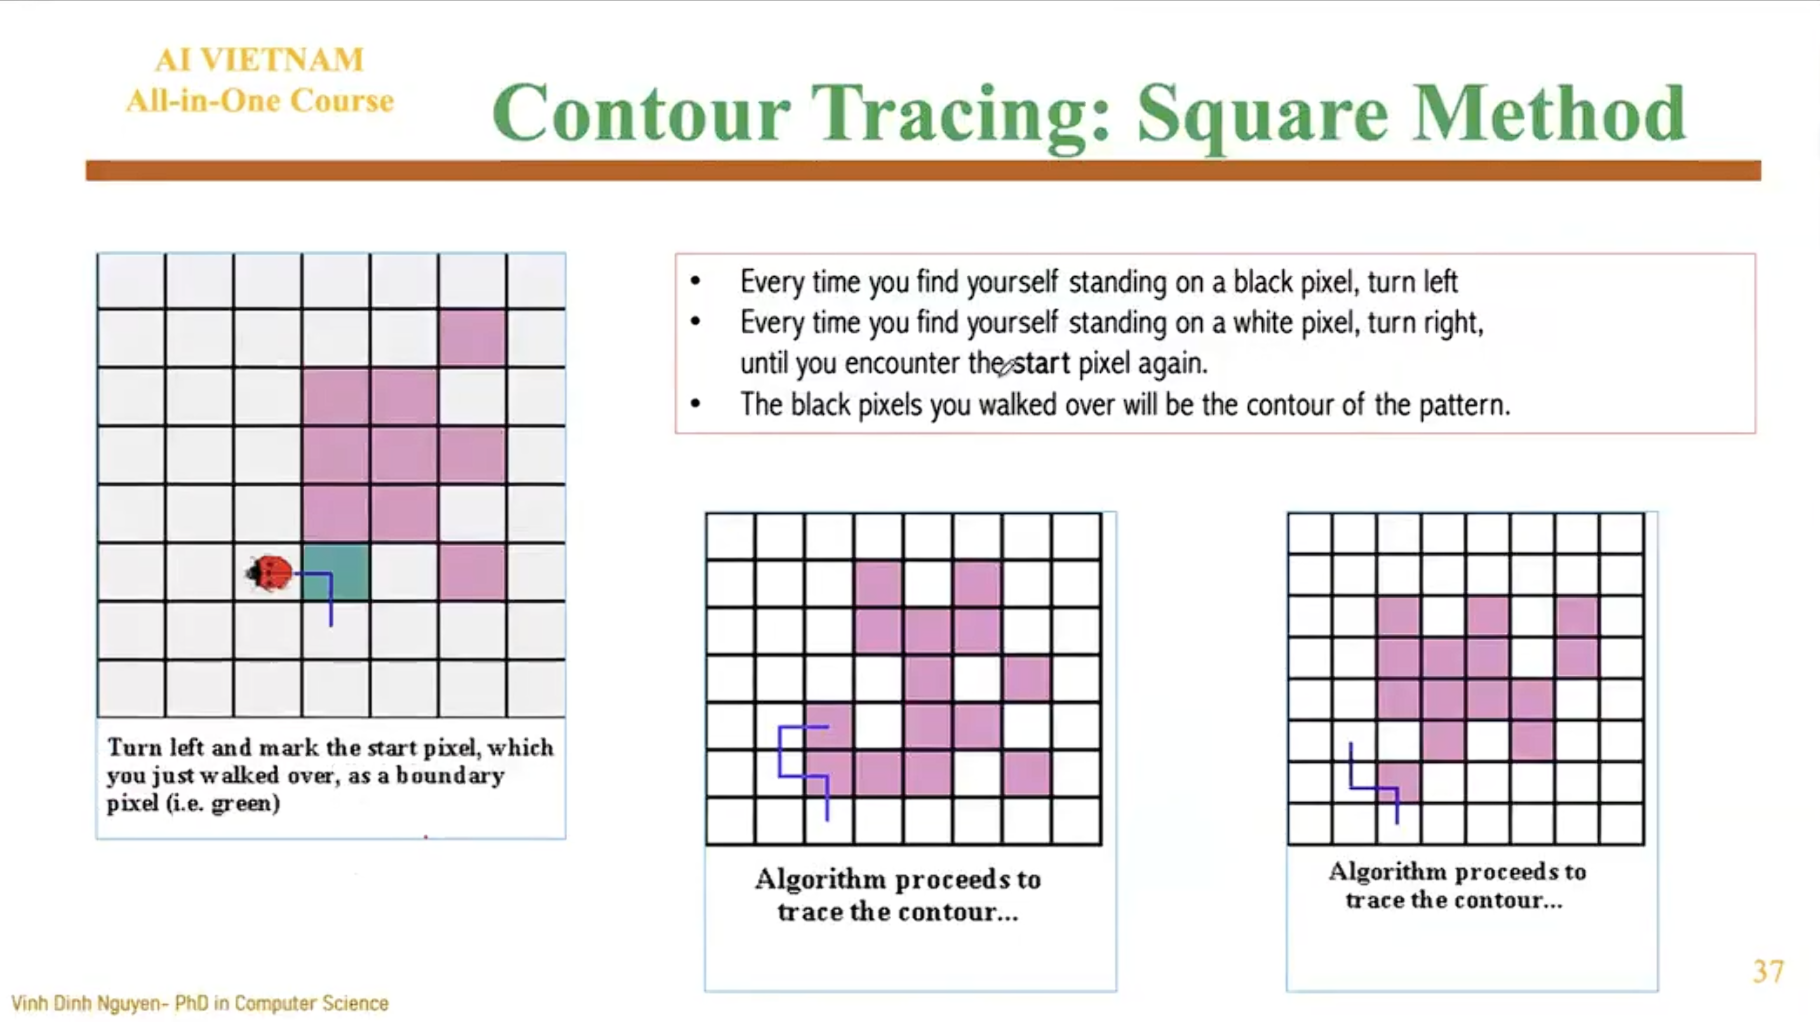

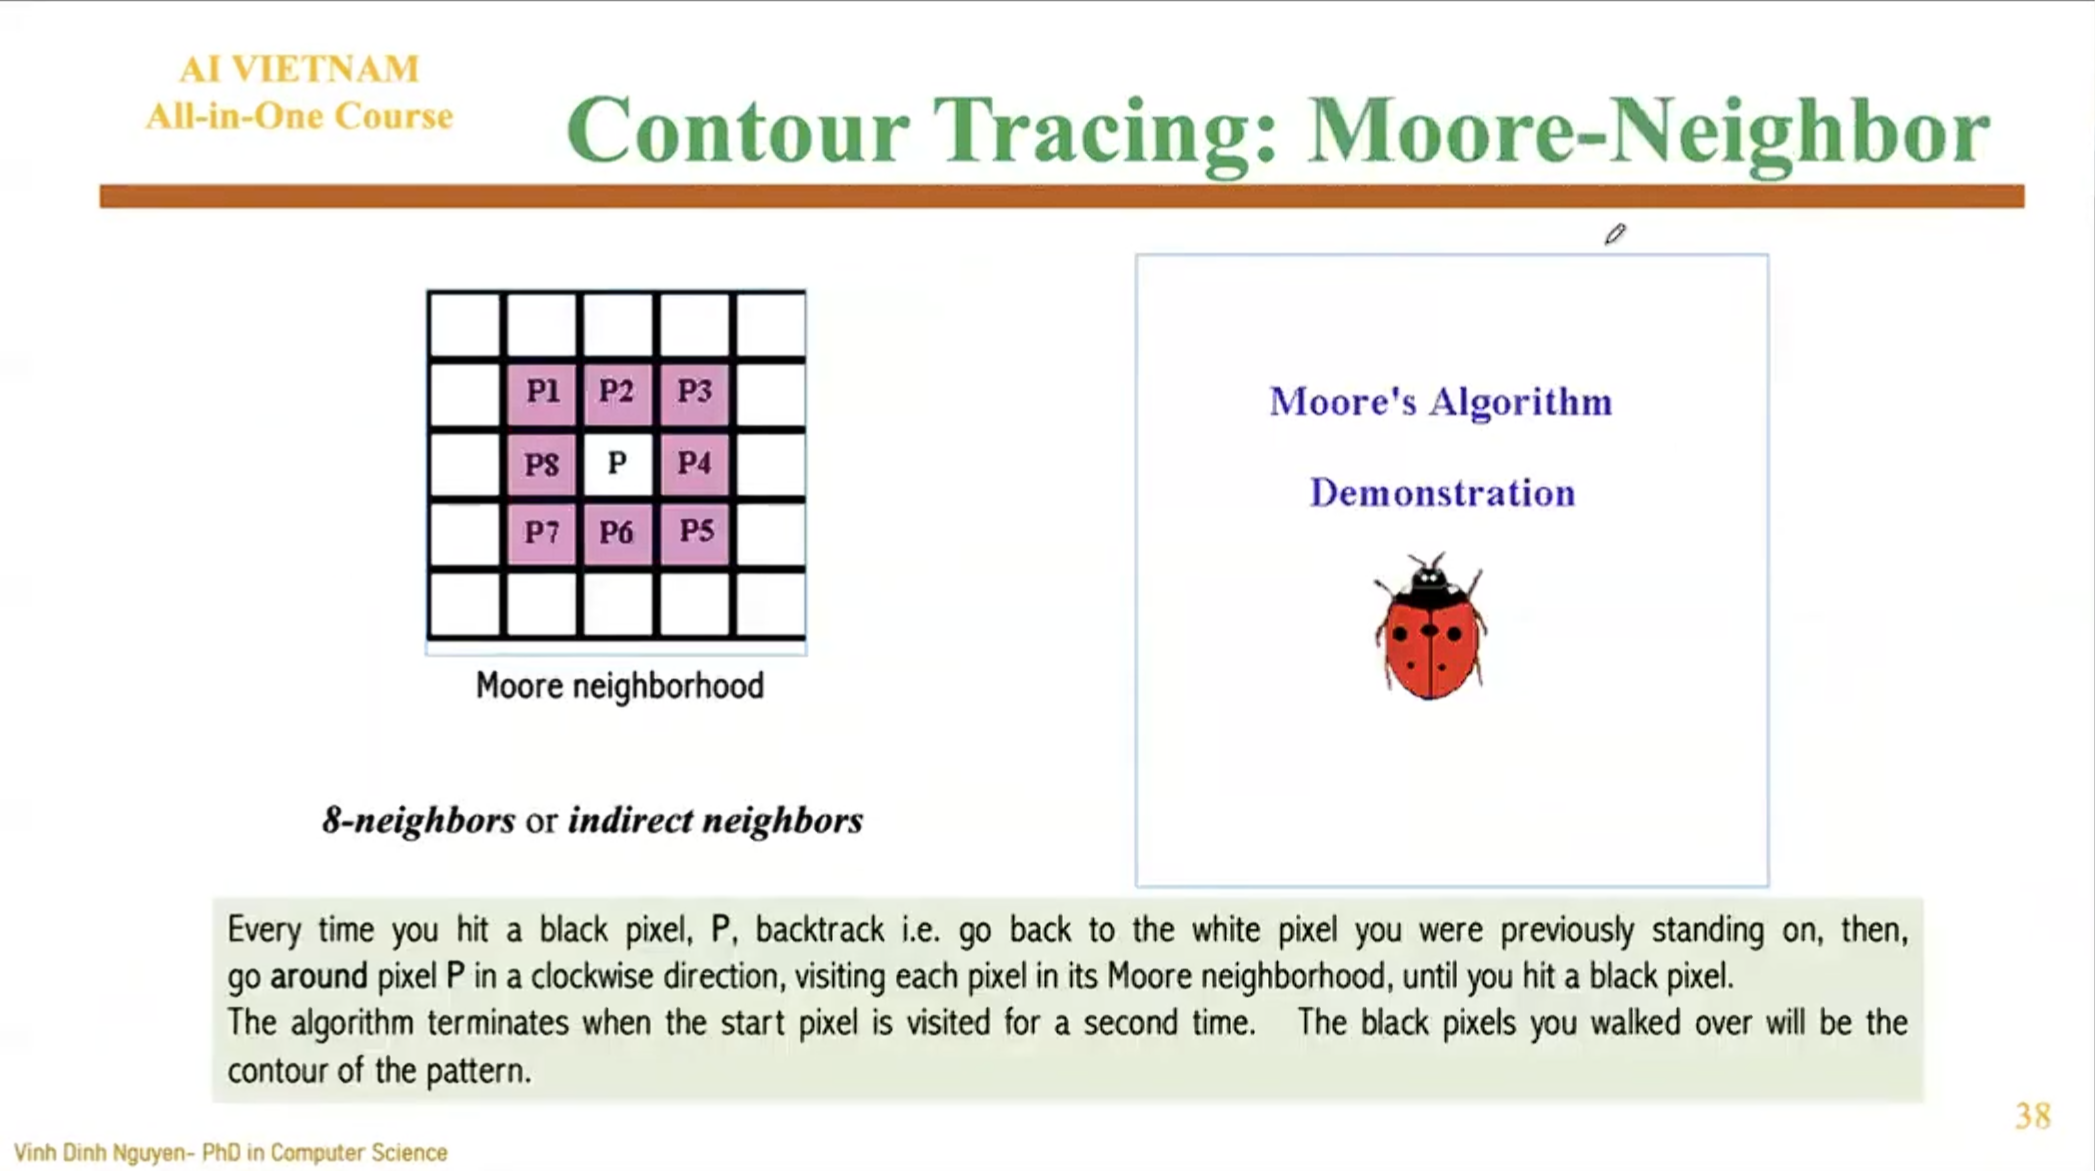

**1. Khái niệm nền tảng: Lân cận Moore (Moore neighborhood)**

- Trước khi dò viền, thuật toán định nghĩa vùng không gian xung quanh một điểm. Như hình minh họa bên trái, "Lân cận Moore" của một pixel trung tâm P bao gồm 8 pixel bao bọc xung quanh nó (được đánh số từ P1 đến P8). Khái niệm này còn được gọi là "8-neighbors" (8 điểm lân cận).

**2. Cơ chế di chuyển để tìm viền**

Thuật toán hoạt động theo các bước lặp lại như sau, dựa trên đoạn văn bản trong hình:
- Bước 1: Đụng vật thể và Lùi lại (Backtrack): Hãy tưởng tượng bạn đang quét qua bức ảnh trên các pixel nền (pixel trắng). Mỗi khi bạn đụng trúng một pixel thuộc về vật thể (pixel đen, được gọi là P), điều đầu tiên bạn làm là lùi lại (backtrack), tức là quay về đứng ở vị trí pixel trắng ngay trước đó.

- Bước 2: Đi vòng quanh (Go around): Từ vị trí pixel trắng vừa lùi lại đó, bạn bắt đầu đi vòng quanh pixel P theo chiều kim đồng hồ (clockwise direction). Bạn sẽ lần lượt "thăm" (kiểm tra) các pixel nằm trong "lân cận Moore" (8 ô xung quanh) của P.

- Bước 3: Bắt được điểm viền mới: Bạn cứ quét vòng quanh theo chiều kim đồng hồ như vậy cho đến khi bạn đụng phải một pixel đen khác. Pixel đen mới tìm thấy này sẽ trở thành điểm P tiếp theo của bạn.

- Bước 4: Điều kiện dừng: Quá trình đụng pixel đen -> lùi lại -> quét vòng quanh này cứ lặp đi lặp lại. Thuật toán sẽ chính thức kết thúc khi điểm xuất phát ban đầu (start pixel) được "thăm" lại lần thứ hai.

Kết quả cuối cùng: Tất cả các pixel đen mà bạn đã đi qua trong suốt quá trình trên sẽ tạo thành đường viền (contour) bao quanh vật thể.

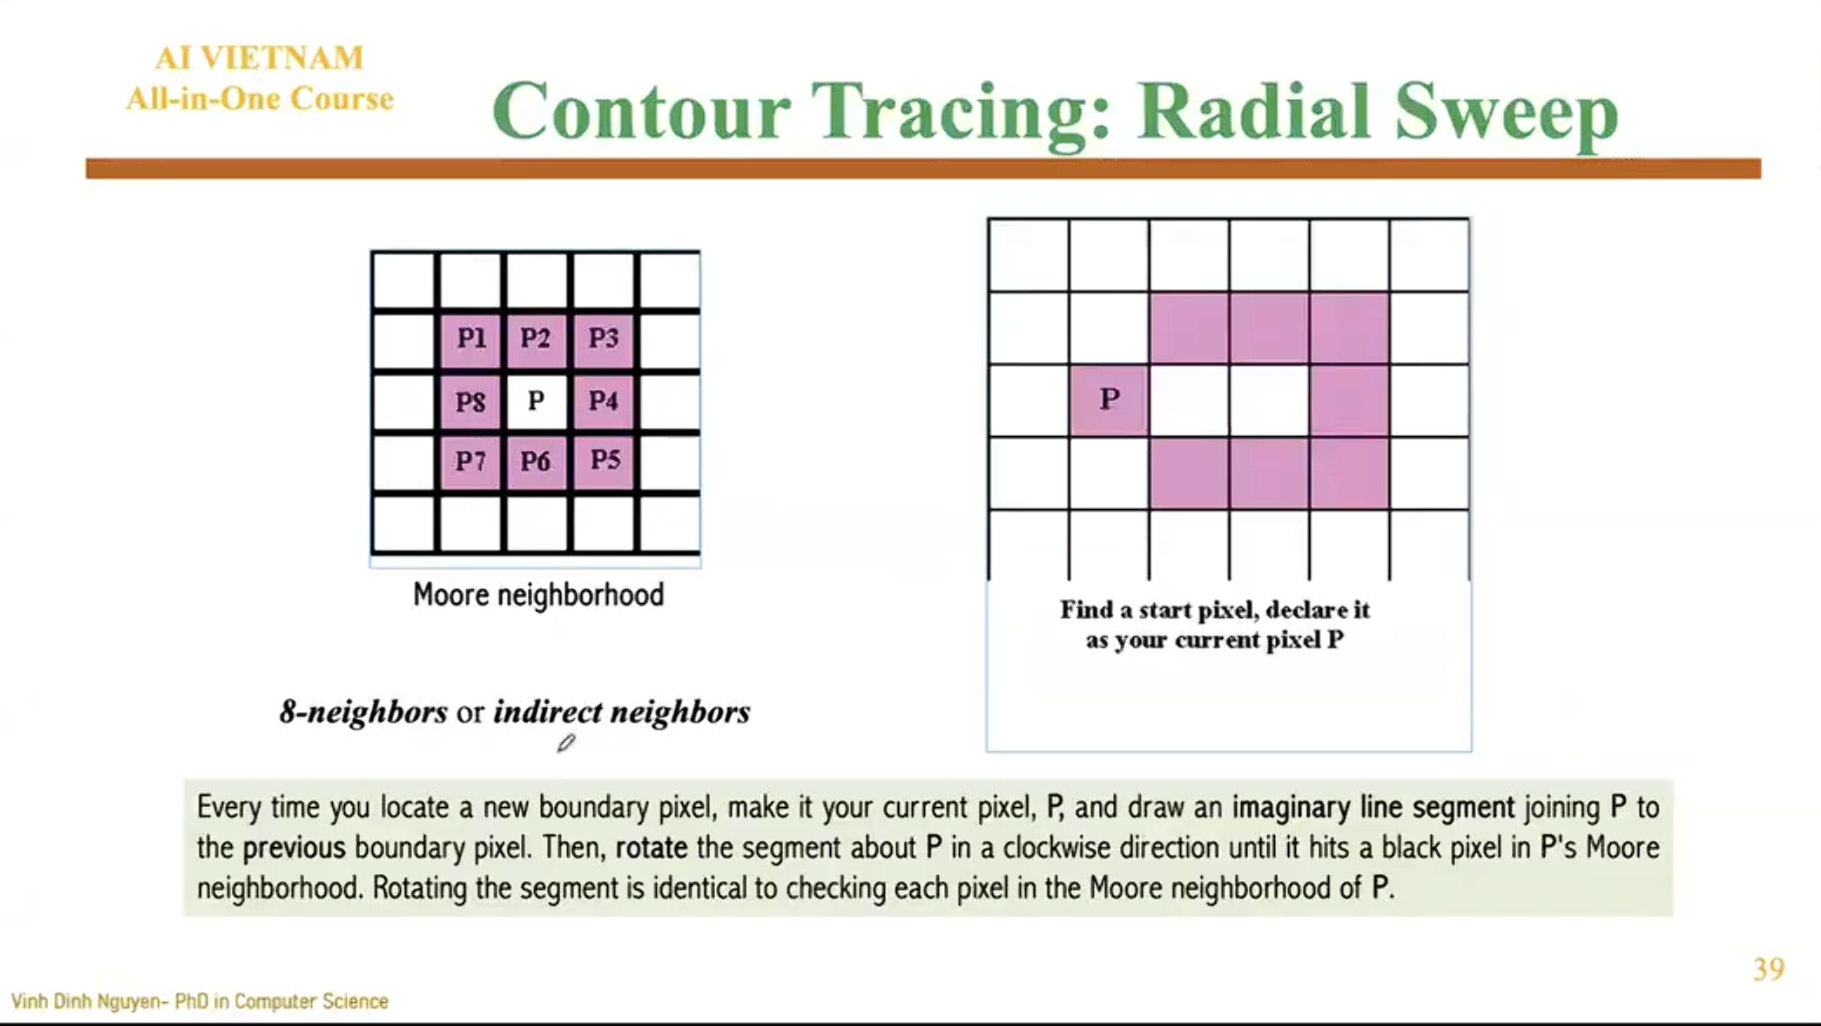

**Cơ chế hoạt động của Radial Sweep**

- Bước 1: Khởi tạo. Tìm một pixel đầu tiên thuộc ranh giới vật thể và đặt nó làm pixel hiện tại, gọi là P.

- Bước 2: Vẽ đường thẳng ảo. Mỗi khi bạn xác định được một pixel viền mới (trở thành P), hãy vẽ một đoạn thẳng tưởng tượng nối từ điểm P hiện tại ngược về pixel viền ngay trước đó (previous boundary pixel).

- Bước 3: Quét xoay vòng. Lấy điểm P làm tâm, bạn bắt đầu xoay đoạn thẳng tưởng tượng đó theo chiều kim đồng hồ (clockwise direction). Trong hình có nhấn mạnh rằng việc xoay đoạn thẳng này thực chất hoàn toàn giống với việc bạn đi kiểm tra lần lượt từng ô một trong không gian lân cận Moore của P.

- Bước 4: Xác định điểm đi tiếp. Quá trình xoay (hoặc kiểm tra) sẽ dừng lại ngay khi nó đụng phải một pixel đen (black pixel - tức là một điểm thuộc về vật thể) nằm trong vùng lân cận đó.

- Bước 5: Cập nhật. Pixel đen vừa bị đụng trúng đó sẽ lập tức trở thành điểm P mới, và quá trình "nối đường thẳng ảo - xoay để tìm điểm mới" lại tiếp tục lặp lại để men dọc theo khối hình.

- Hình dung thực tế: Bạn hãy tưởng tượng mình đang neo một đầu sợi dây vào điểm P, đầu kia kéo căng về điểm viền vừa đi qua. Sau đó, bạn cầm sợi dây quét thành một vòng cung theo chiều kim đồng hồ. Vật cản đầu tiên sợi dây chạm vào (pixel đen lân cận) chính là viên gạch tiếp theo của đường viền.

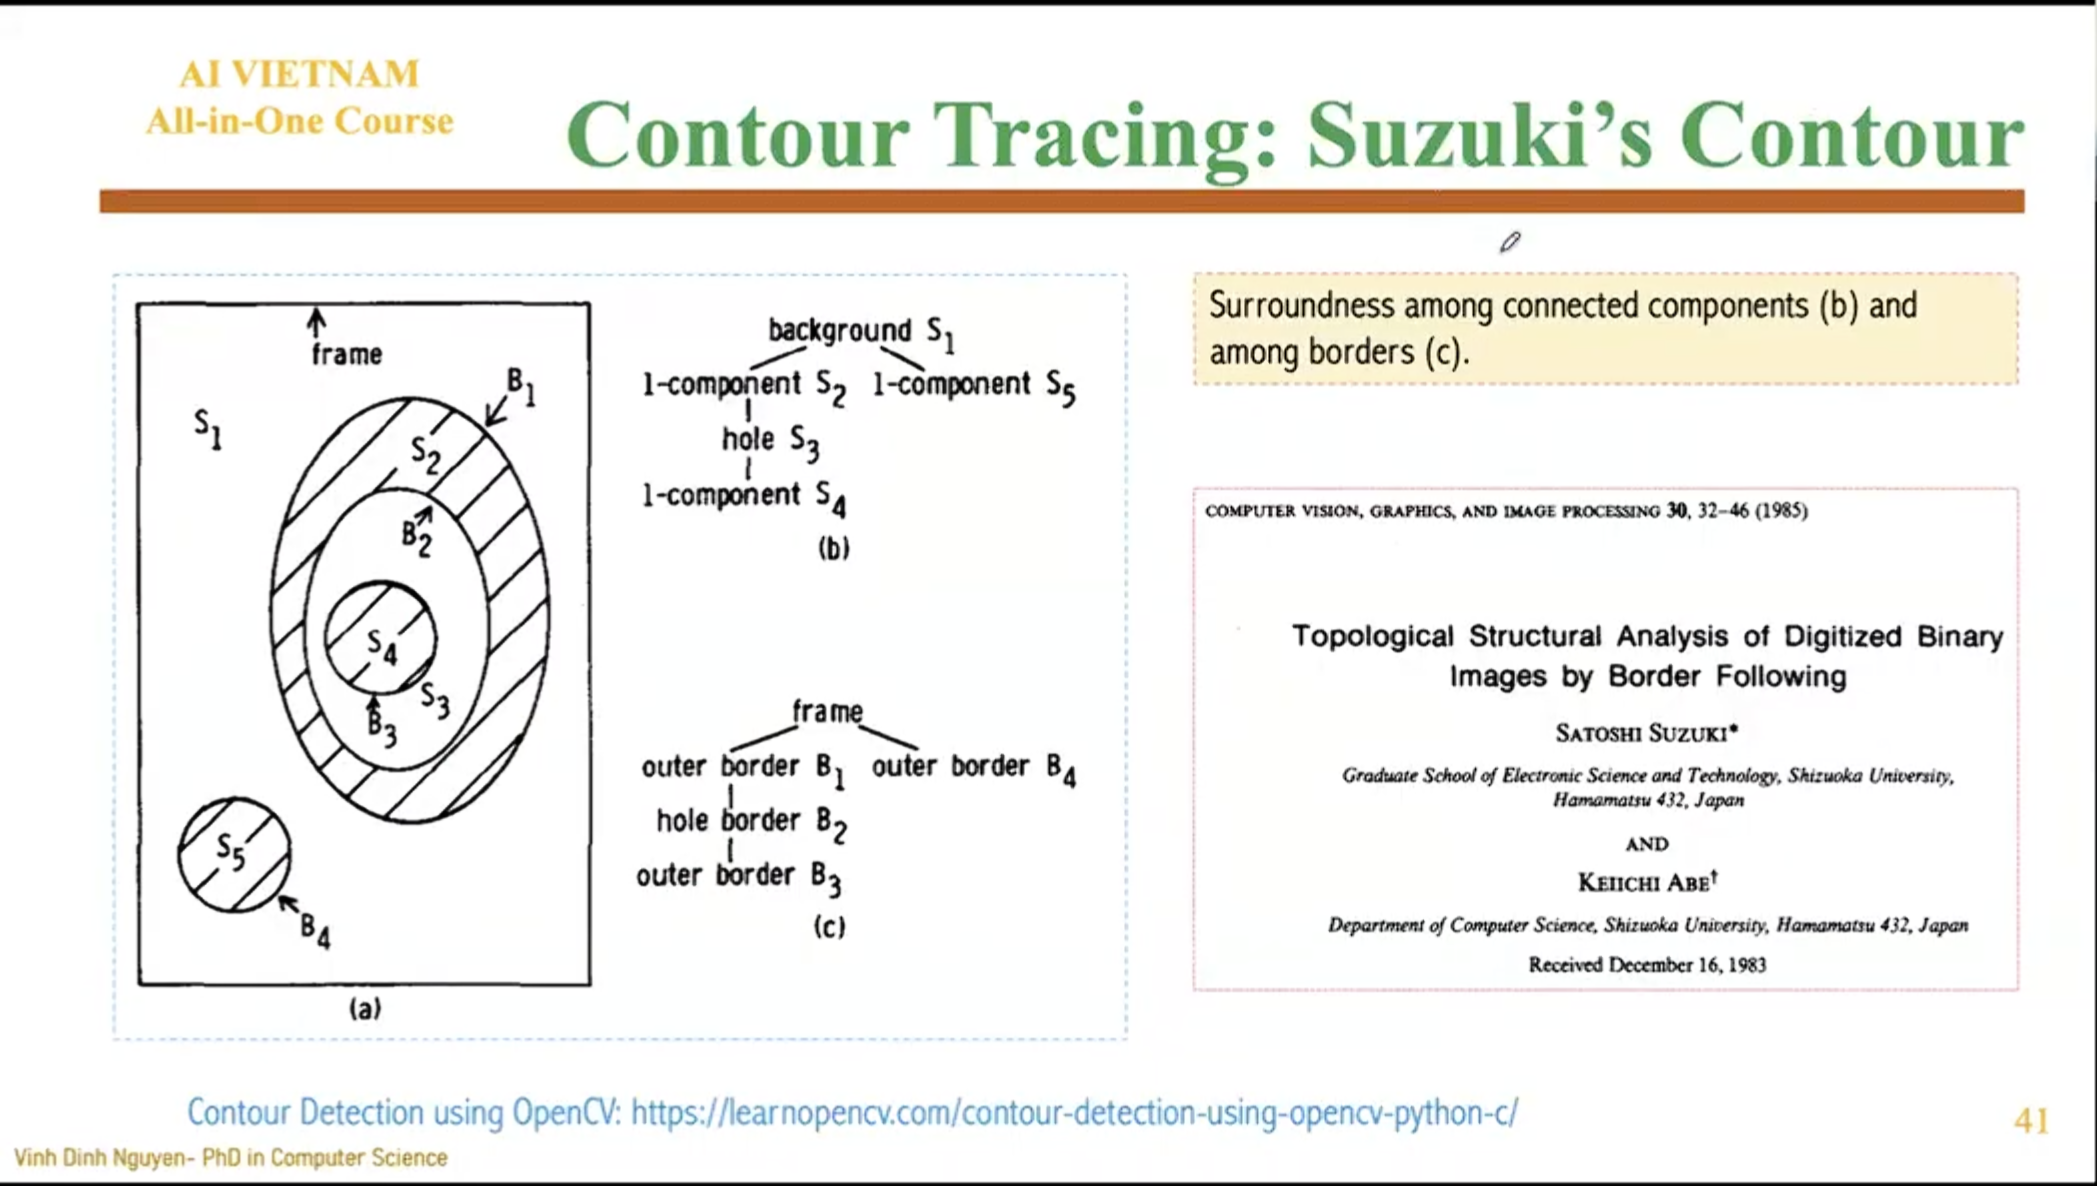

Nếu các thuật toán trước (Square, Moore, Radial) giống như một con bọ mù mờ chỉ biết đi men theo một bờ tường duy nhất, thì thuật toán do Satoshi Suzuki và Keiichi Abe công bố năm 1985 giống như một chiếc flycam quét qua toàn bộ bản đồ.

Đặc biệt, đây chính là thuật toán nền tảng đang chạy ngầm bên trong hàm cv2.findContours() rất nổi tiếng của thư viện OpenCV.

**1. Mục tiêu cốt lõi: Phân tích cấu trúc Topo (Topological Structural Analysis)**

- Điểm khác biệt lớn nhất của Suzuki là nó không chỉ tìm ra các đường viền, mà nó còn tìm ra mối quan hệ bao hàm (Surroundness) giữa chúng. Nó biết chính xác đường viền nào nằm bên trong đường viền nào (giống như búp bê Nga).

**2. Phân loại Viền: Outer Border vs Hole Border**

Hãy nhìn vào hình (a), thuật toán chia đường viền làm 2 loại chính:
- Outer border (Viền ngoài): Là ranh giới bao bọc bên ngoài của một vật thể nét liền. Ví dụ: $B_1$ bao bọc vật thể to $S_2$, $B_4$ bao bọc vật thể nhỏ $S_5$, và $B_3$ bao bọc vật thể $S_4$.
- Hole border (Viền lỗ): Là ranh giới rỗng nằm bên trong một vật thể. Ví dụ: Vật thể $S_2$ bị khoét một cái lỗ $S_3$ ở giữa, ranh giới của cái lỗ đó chính là viền $B_2$.

**3. Cơ chế xây dựng Cây phả hệ (Hierarchy Tree)**

Thuật toán sẽ quét bức ảnh (thường là ảnh nhị phân từ trên xuống dưới, từ trái qua phải). Mỗi khi phát hiện ra một đường viền mới, nó sẽ tự động xếp đường viền đó vào một Cây cấu trúc gia đình như ở hình (b) và (c):
- Hình (b) - Sơ đồ vùng không gian (Connected components): Nền tổng $S_1$ chứa vật thể $S_2$ và vật thể $S_5$. Vật thể $S_2$ lại chứa lỗ $S_3$. Bên trong lỗ rỗng $S_3$ lại lòi ra một vật thể con $S_4$.
- Hình (c) - Sơ đồ đường viền (Borders): Khung ảnh ngoài cùng (frame) là "Cụ tổ", sinh ra hai viền ngoài là $B_1$ và $B_4$. $B_1$ đóng vai trò là "Cha" của viền lỗ $B_2$. Tiếp theo, viền lỗ $B_2$ lại là "Cha" của viền ngoài $B_3$ nằm tít bên trong.

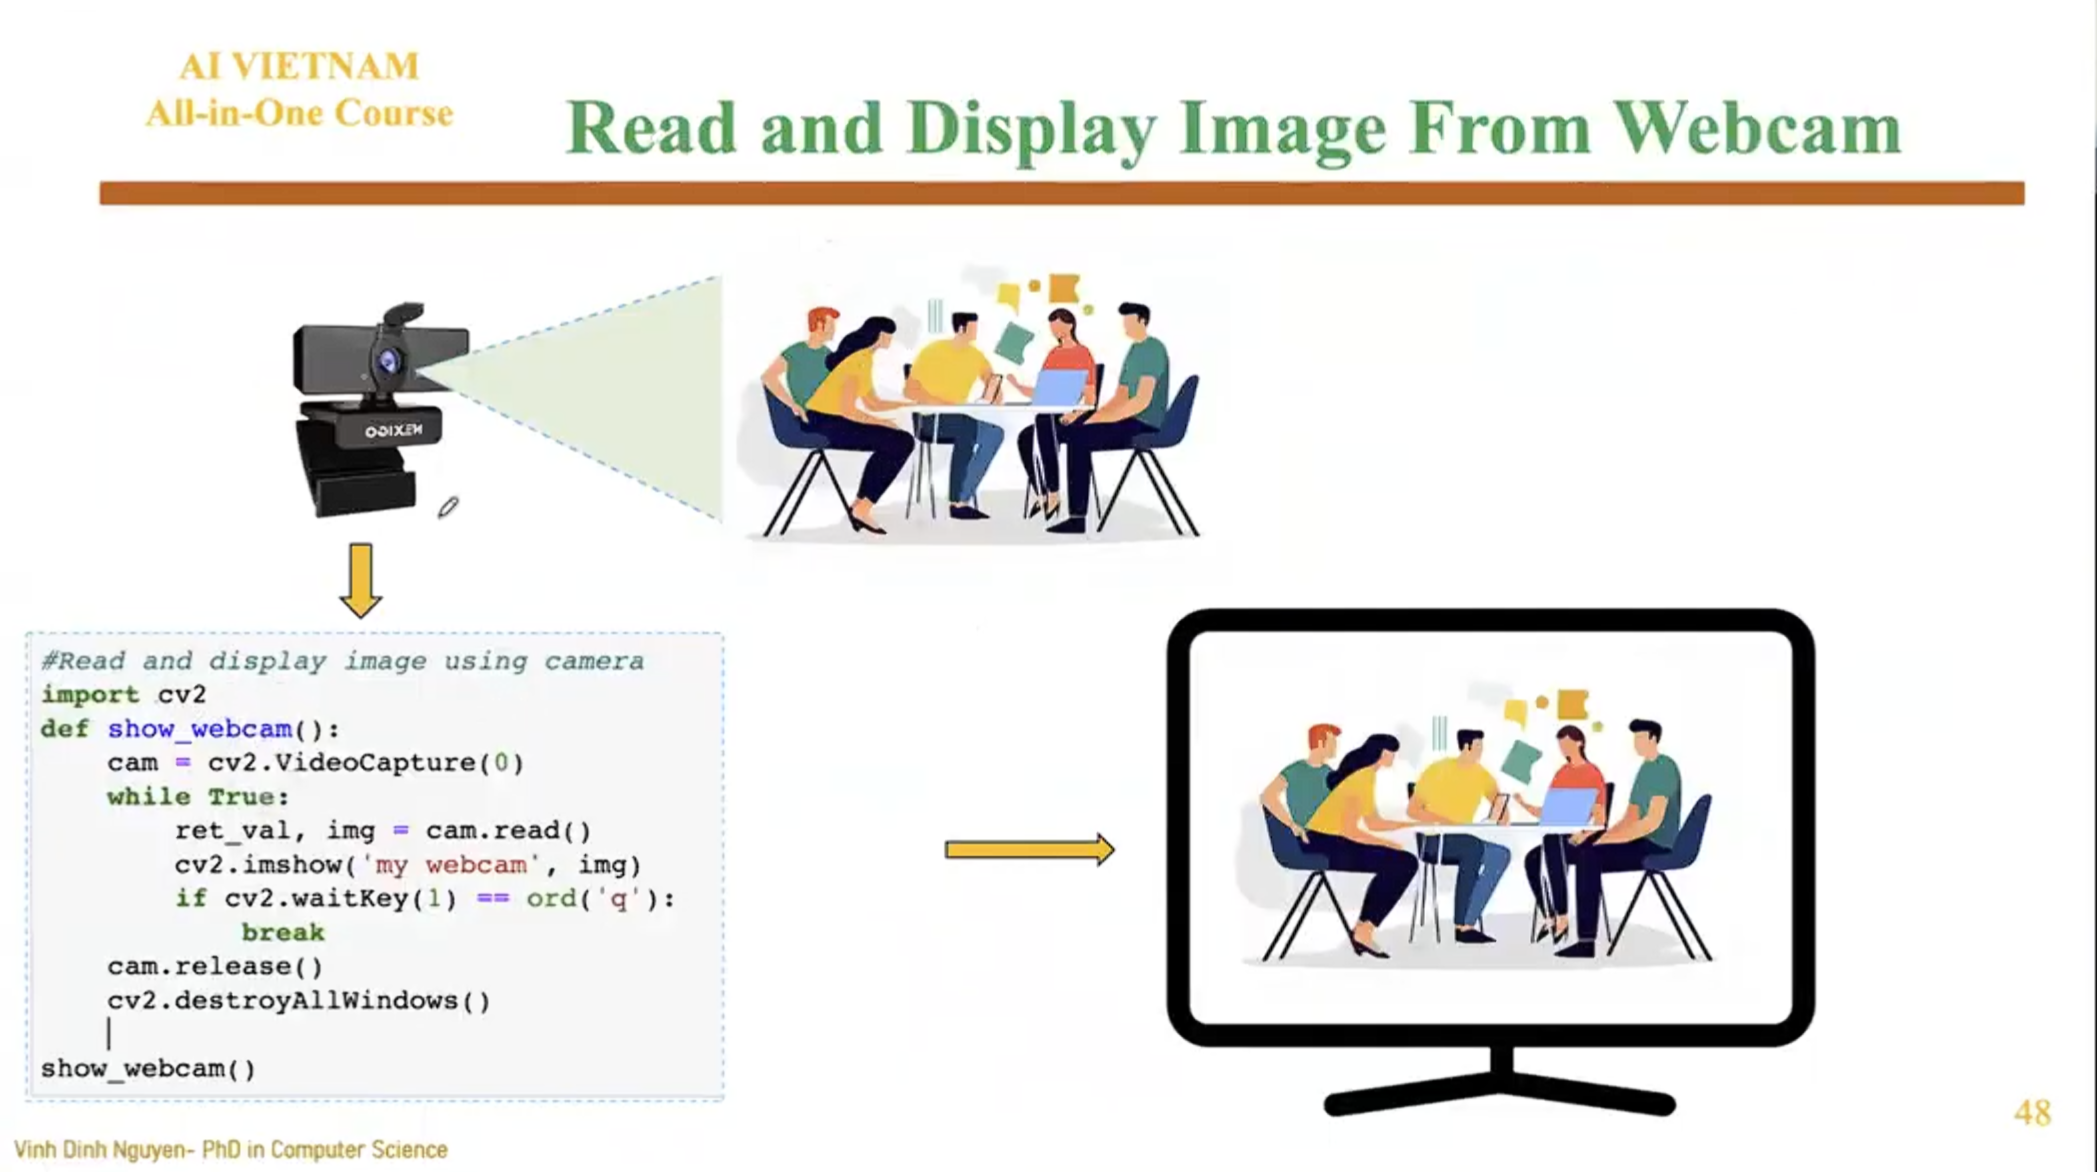

In [6]:
import cv2
def show_webcam():
    cam = cv2.VideoCapture(0)
    while True:
        ret_val, img = cam.read()
        cv2.imshow('my webcam', img)
        if cv2.waitKey(1) == ord('q'):
            break
    cam.release()
    cv2.destroyAllWindows()
show_webcam()